# Real Estate Price Modeling Notebook

This notebook explores a real-estate dataset with the goal of understanding how property characteristics relate to price and how well different machine learning models can predict price categories or price values. The workflow starts with data loading and cleaning, continues through exploratory analysis and visualization, and ends with classification and regression modeling.

The notebook is structured in a practical, portfolio-friendly way so that each stage is easy to follow and explain later in a presentation or write-up.

## What this notebook covers
- Loading and preparing the dataset
- Cleaning columns and converting data types
- Exploring price distribution and relationships with property features
- Building classification models for price bands
- Building regression models for continuous price prediction
- Reviewing the results and identifying next improvements

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    root_mean_squared_error
)
from sklearn.metrics import (
    # Core metrics
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,

    # Multi-metric reports
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,

    # Probabilistic / ranking
    roc_auc_score,
    roc_curve
)

In [2]:
try:
    data = pd.read_csv('/content/nig_properties_combined.csv')
    data.head(3)
except FileNotFoundError:
    print("Sorry!\nNot in Colab Environment, File not found.\nTrying to load from local path...")
    data = pd.read_csv('Datasets/nig_properties_combined.csv')
    data.head(3)
except Exception as e:
    print(f"An error occurred: {e}")

Sorry!
Not in Colab Environment, File not found.
Trying to load from local path...


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18883 entries, 0 to 18882
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Title          18883 non-null  object 
 1   Address        18883 non-null  object 
 2   Property Type  18883 non-null  object 
 3   Location       18883 non-null  object 
 4   State          18883 non-null  object 
 5   Bedrooms       18883 non-null  int64  
 6   Bathrooms      18883 non-null  int64  
 7   Toilets        18883 non-null  float64
 8   Date Listed    18883 non-null  object 
 9   Prices         18883 non-null  int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 1.4+ MB


In [4]:
data['Toilets'] = data['Toilets'].astype(int)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18883 entries, 0 to 18882
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Title          18883 non-null  object
 1   Address        18883 non-null  object
 2   Property Type  18883 non-null  object
 3   Location       18883 non-null  object
 4   State          18883 non-null  object
 5   Bedrooms       18883 non-null  int64 
 6   Bathrooms      18883 non-null  int64 
 7   Toilets        18883 non-null  int64 
 8   Date Listed    18883 non-null  object
 9   Prices         18883 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 1.4+ MB


In [5]:
data['Date Listed']

0        2026-06-10
1        2026-06-23
2        2026-06-23
3        2026-06-23
4        2026-06-23
            ...    
18878    2026-05-23
18879    2025-12-19
18880    2025-07-30
18881    2025-04-30
18882    2026-05-07
Name: Date Listed, Length: 18883, dtype: object

In [6]:
data['Date Listed'] = pd.to_datetime(data['Date Listed'])

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18883 entries, 0 to 18882
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Title          18883 non-null  object        
 1   Address        18883 non-null  object        
 2   Property Type  18883 non-null  object        
 3   Location       18883 non-null  object        
 4   State          18883 non-null  object        
 5   Bedrooms       18883 non-null  int64         
 6   Bathrooms      18883 non-null  int64         
 7   Toilets        18883 non-null  int64         
 8   Date Listed    18883 non-null  datetime64[ns]
 9   Prices         18883 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(5)
memory usage: 1.4+ MB


In [8]:
data['Prices'].mean()

np.float64(13805343.982206218)

In [9]:
data[data['Prices'] > 14500000].shape

(5448, 10)

In [10]:
data['Price_label'] = pd.cut(
    data['Prices'],
    bins=[0, 5000000, 20000000, float('inf')],
    labels=[0, 1, 2]
)  # budget / mid-range / luxury

In [11]:
data['State'].unique()

array(['Lagos', 'Edo', 'Abuja', 'Ogun', 'Rivers', 'Oyo', 'Imo', 'Enugu',
       'Kano', 'Plateau', 'Abia', 'Borno', 'Akwa Ibom', 'Niger', 'Osun',
       'Ondo', 'Unknown'], dtype=object)

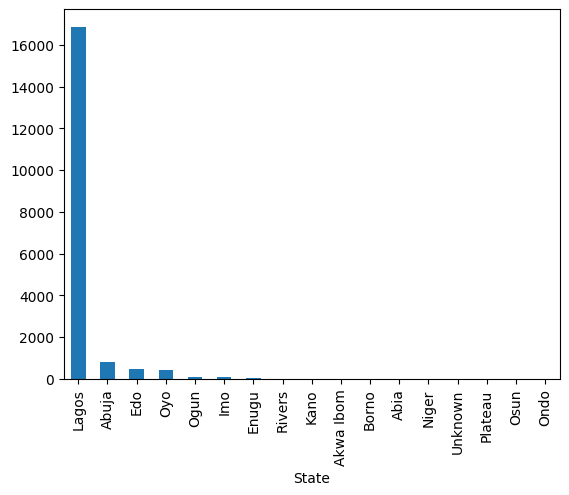

In [12]:
data['State'].value_counts().plot(kind = 'bar')
plt.show()

In [13]:
data[data['State'].str.contains('Lagos')].shape

(16871, 11)

In [14]:
pd.set_option('display.float_format', '{:,.0f}'.format)

In [15]:
df = data[data['State'].str.contains('Lagos')]
df.describe()

,Bedrooms,Bathrooms,Toilets,Date Listed,Prices
count,"16,871","16,871","16,871",16871,"16,871"
mean,2,2,2,2026-03-20 22:20:59.391855872,"14,570,550"
min,0,0,0,2021-07-03 00:00:00,"100,000"
25%,1,1,1,2026-02-26 00:00:00,"2,500,000"
50%,2,2,2,2026-04-23 00:00:00,"5,500,000"
75%,3,3,3,2026-06-01 00:00:00,"20,000,000"
max,10,10,20,2026-09-27 00:00:00,"155,000,000"
std,1,1,2,NaN,"20,215,386"


In [16]:
df = df.drop(
    columns = ['Address',
    'Title',
    'State',
    'Date Listed'
    ]
)

df.columns

Index(['Property Type', 'Location', 'Bedrooms', 'Bathrooms', 'Toilets',
       'Prices', 'Price_label'],
      dtype='object')

In [17]:
df.corr(numeric_only=True)

,Bedrooms,Bathrooms,Toilets,Prices
Bedrooms,1,1,1,1
Bathrooms,1,1,1,0
Toilets,1,1,1,1
Prices,1,0,1,1


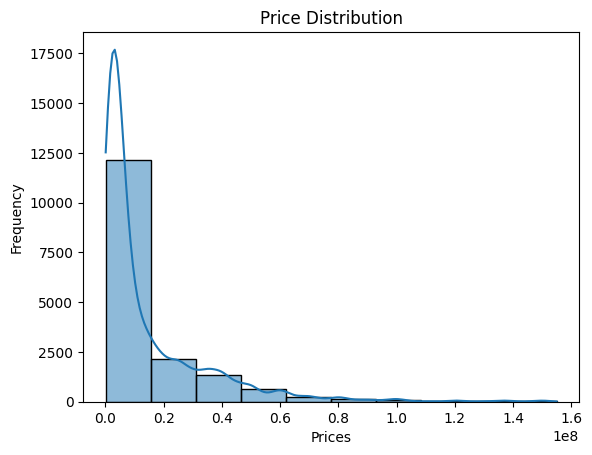

In [18]:
sns.histplot(df['Prices'], kde = True, bins = 10)
plt.title('Price Distribution')
plt.xlabel('Prices')
plt.ylabel('Frequency')
plt.show()

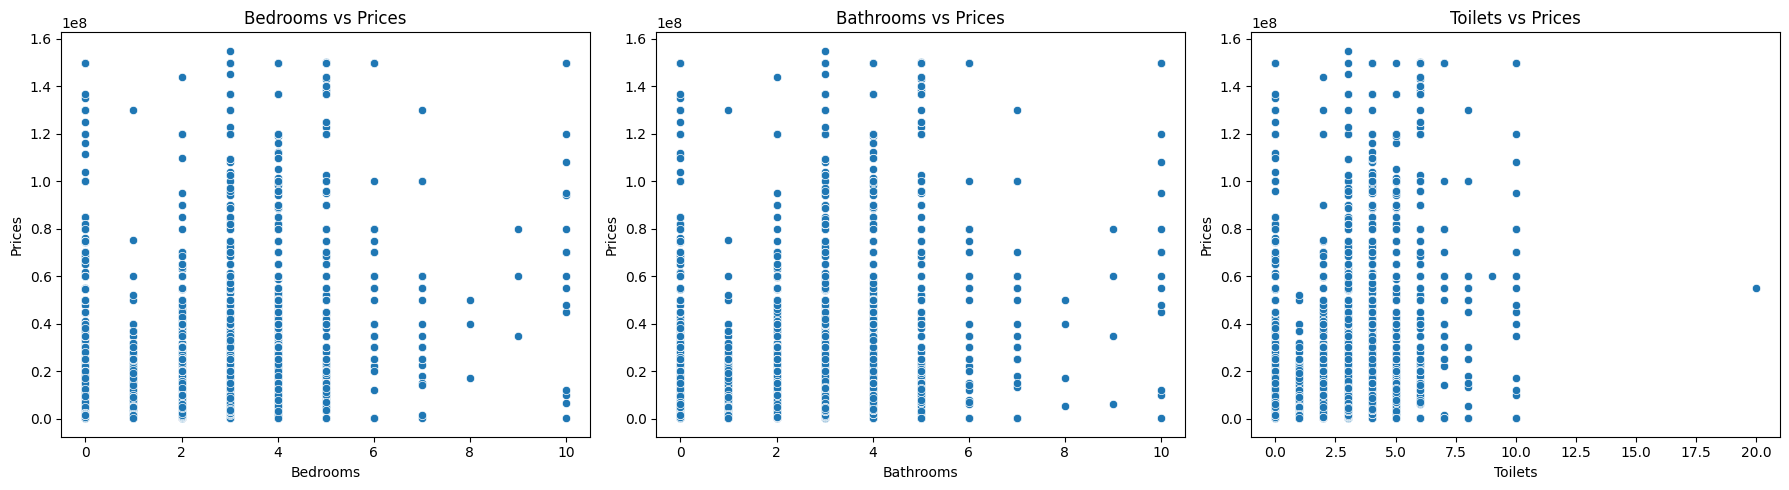

In [19]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
feats = ['Bedrooms', 'Bathrooms', 'Toilets']

for i, feat in enumerate(feats):
  sns.scatterplot(data = df, x = feat, y = 'Prices', ax = axs[i])
  axs[i].set_title(f'{feat} vs Prices')
  axs[i].set_xlabel(feat)
  axs[i].set_ylabel('Prices')

plt.tight_layout()
plt.show()

In [20]:
df[df['Toilets'] > 15]

,Property Type,Location,Bedrooms,Bathrooms,Toilets,Prices,Price_label
6208,Other,Lekki,0,0,20,55000001,2


In [21]:
df[(df['Toilets'] > 10) & (df['Toilets'] <= 15)]

,Property Type,Location,Bedrooms,Bathrooms,Toilets,Prices,Price_label


In [22]:
df = df[df['Toilets'] <= 10]

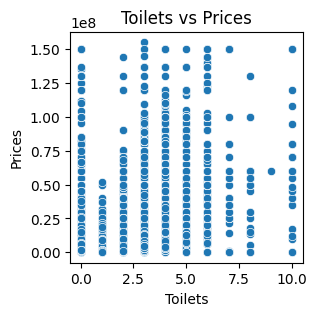

In [23]:
plt.figure(figsize = (3, 3))

sns.scatterplot(data = df, x = 'Toilets', y = 'Prices')
plt.title('Toilets vs Prices')
plt.xlabel('Toilets')
plt.ylabel('Prices')
plt.show()

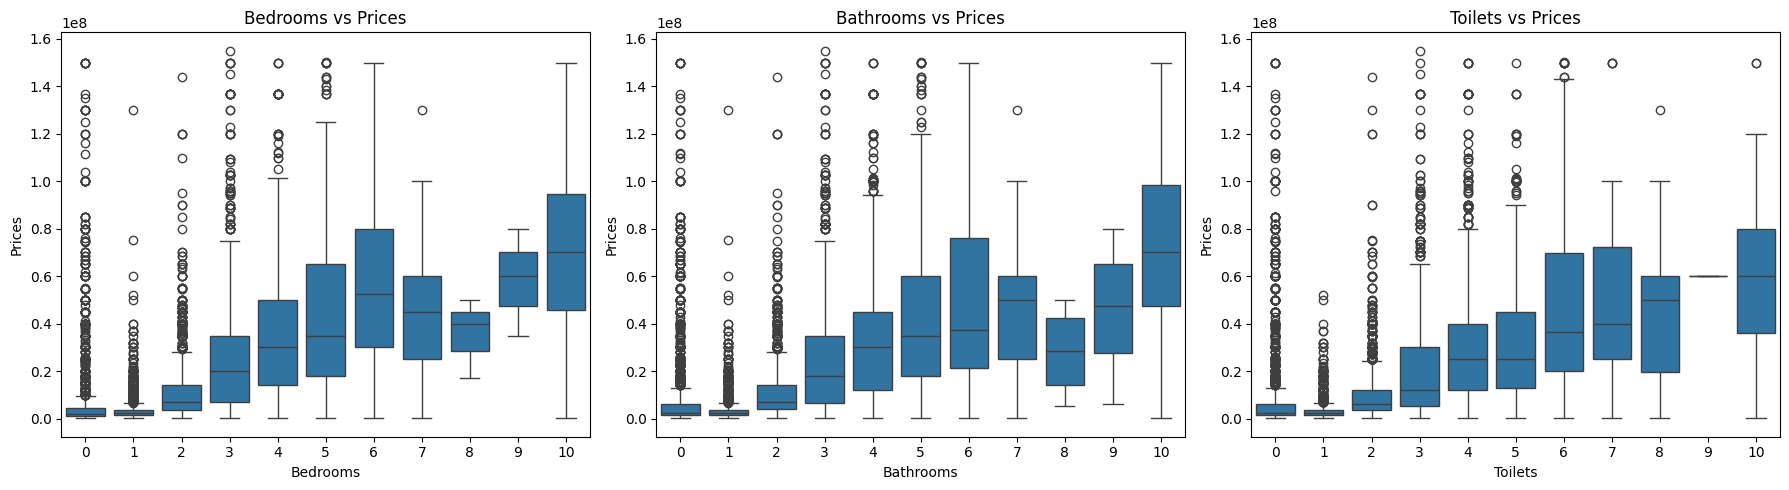

In [24]:
fig, ax = plt.subplots(1, 3, figsize = (18, 5))

for i, feat in enumerate(feats):
  sns.boxplot(data = df, x = feat, y = 'Prices', ax = ax[i])
  ax[i].set_title(f'{feat} vs Prices')
  ax[i].set_xlabel(feat)
  ax[i].set_ylabel('Prices')

plt.tight_layout()
plt.show()

### Boxplot Analysis of Features vs. Prices

The boxplots below show how property prices vary across different bedroom, bathroom, and toilet counts. These visualizations help reveal whether larger homes tend to be more expensive and whether the spread of prices increases as the number of rooms grows.

Key takeaway:
- Properties with more rooms generally trend toward higher prices.
- However, the price range is still wide, which suggests that other factors also influence value.

These plots are useful because they show both central tendency and spread, making it easier to judge whether the variables appear meaningful before fitting a model.

In [25]:
Q1 = df['Prices'].quantile(0.25)
Q3 = df['Prices'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Prices'] >= Q1 - 1.5*IQR) & (df['Prices'] <= Q3 + 1.5*IQR)]
df.shape, df.describe()

((15669, 7),
        Bedrooms  Bathrooms  Toilets     Prices
 count    15,669     15,669   15,669     15,669
 mean          2          2        2 10,262,536
 std           1          1        2 11,594,588
 min           0          0        0    100,000
 25%           1          1        1  2,300,000
 50%           2          2        2  5,000,000
 75%           3          3        3 15,000,000
 max          10         10       10 46,000,000)

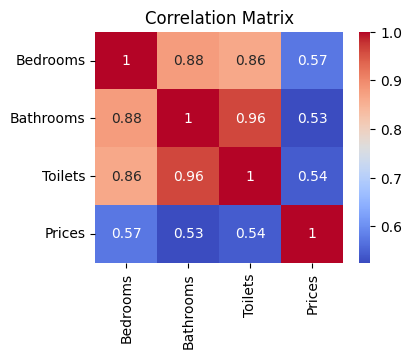

In [26]:
plt.figure(figsize = (4, 3))

sns.heatmap(df.corr(numeric_only=True), annot = True, cmap = 'coolwarm')
plt.title('Correlation Matrix')
plt.show()

### Correlation Matrix Heatmap Analysis

The correlation heatmap highlights how strongly the numerical features relate to one another and to price. This is helpful for understanding whether some features are redundant or whether the variables appear to contain useful signal for prediction.

Key takeaway:
- Bedrooms, bathrooms, and toilets are all positively related to price.
- Some of these variables are strongly correlated with each other, which can create redundancy in a regression model.
- The correlation matrix helps justify the later decision to simplify the feature set and experiment with different modeling approaches.

In [27]:
df = df.drop(columns = 'Toilets')
df.columns

Index(['Property Type', 'Location', 'Bedrooms', 'Bathrooms', 'Prices',
       'Price_label'],
      dtype='object')

In [28]:
df['Location'].nunique()

38

In [29]:
df['Property Type'].nunique()

9

In [30]:
# Property Type vs Prices
df.groupby('Property Type')['Prices'].mean().sort_values(ascending=False).map('{:,.0f}'.format)

Property Type
Other                              19,251,500
Self Contain / Shared Room         19,135,762
Terraced Duplex                    17,513,371
Land                               16,475,000
Commercial Property                12,891,032
Luxury Apartment                   12,570,329
Detached / Semi-Detached Duplex    10,469,034
Mini Flat                           3,040,276
Standard Flat / Apartment           2,904,766
Name: Prices, dtype: object

In [31]:
df.groupby('Location')['Prices'].mean().sort_values(ascending=False).map('{:,.0f}'.format)

Location
Ikoyi              31,430,285
Victoria Island    23,686,644
Apapa              12,780,000
Ikeja               9,962,932
Lekki               9,429,228
Maryland            8,266,327
Katampe             7,500,000
Lagos Island        6,740,385
Epe                 6,707,396
Kosofe Ikosi        5,502,404
Ilupeju             4,883,333
Ogudu               4,721,296
Amuwo Odofin        4,185,455
Ojo                 4,145,166
Gbagada             4,048,840
Surulere            3,258,696
Yaba                3,069,400
Ogba                3,022,986
Agege               2,972,549
Ajah                2,966,374
Okota               2,895,567
Iju                 2,875,000
Ketu                2,728,947
Ibeju Lekki         2,717,647
Isolo               2,449,438
Orile               2,200,000
Shomolu             2,193,829
Abule Egba          1,960,465
Egbe Idimu          1,926,786
Mushin              1,897,674
Extension           1,850,000
Ikorodu             1,689,218
Ipaja               1,547,636
B

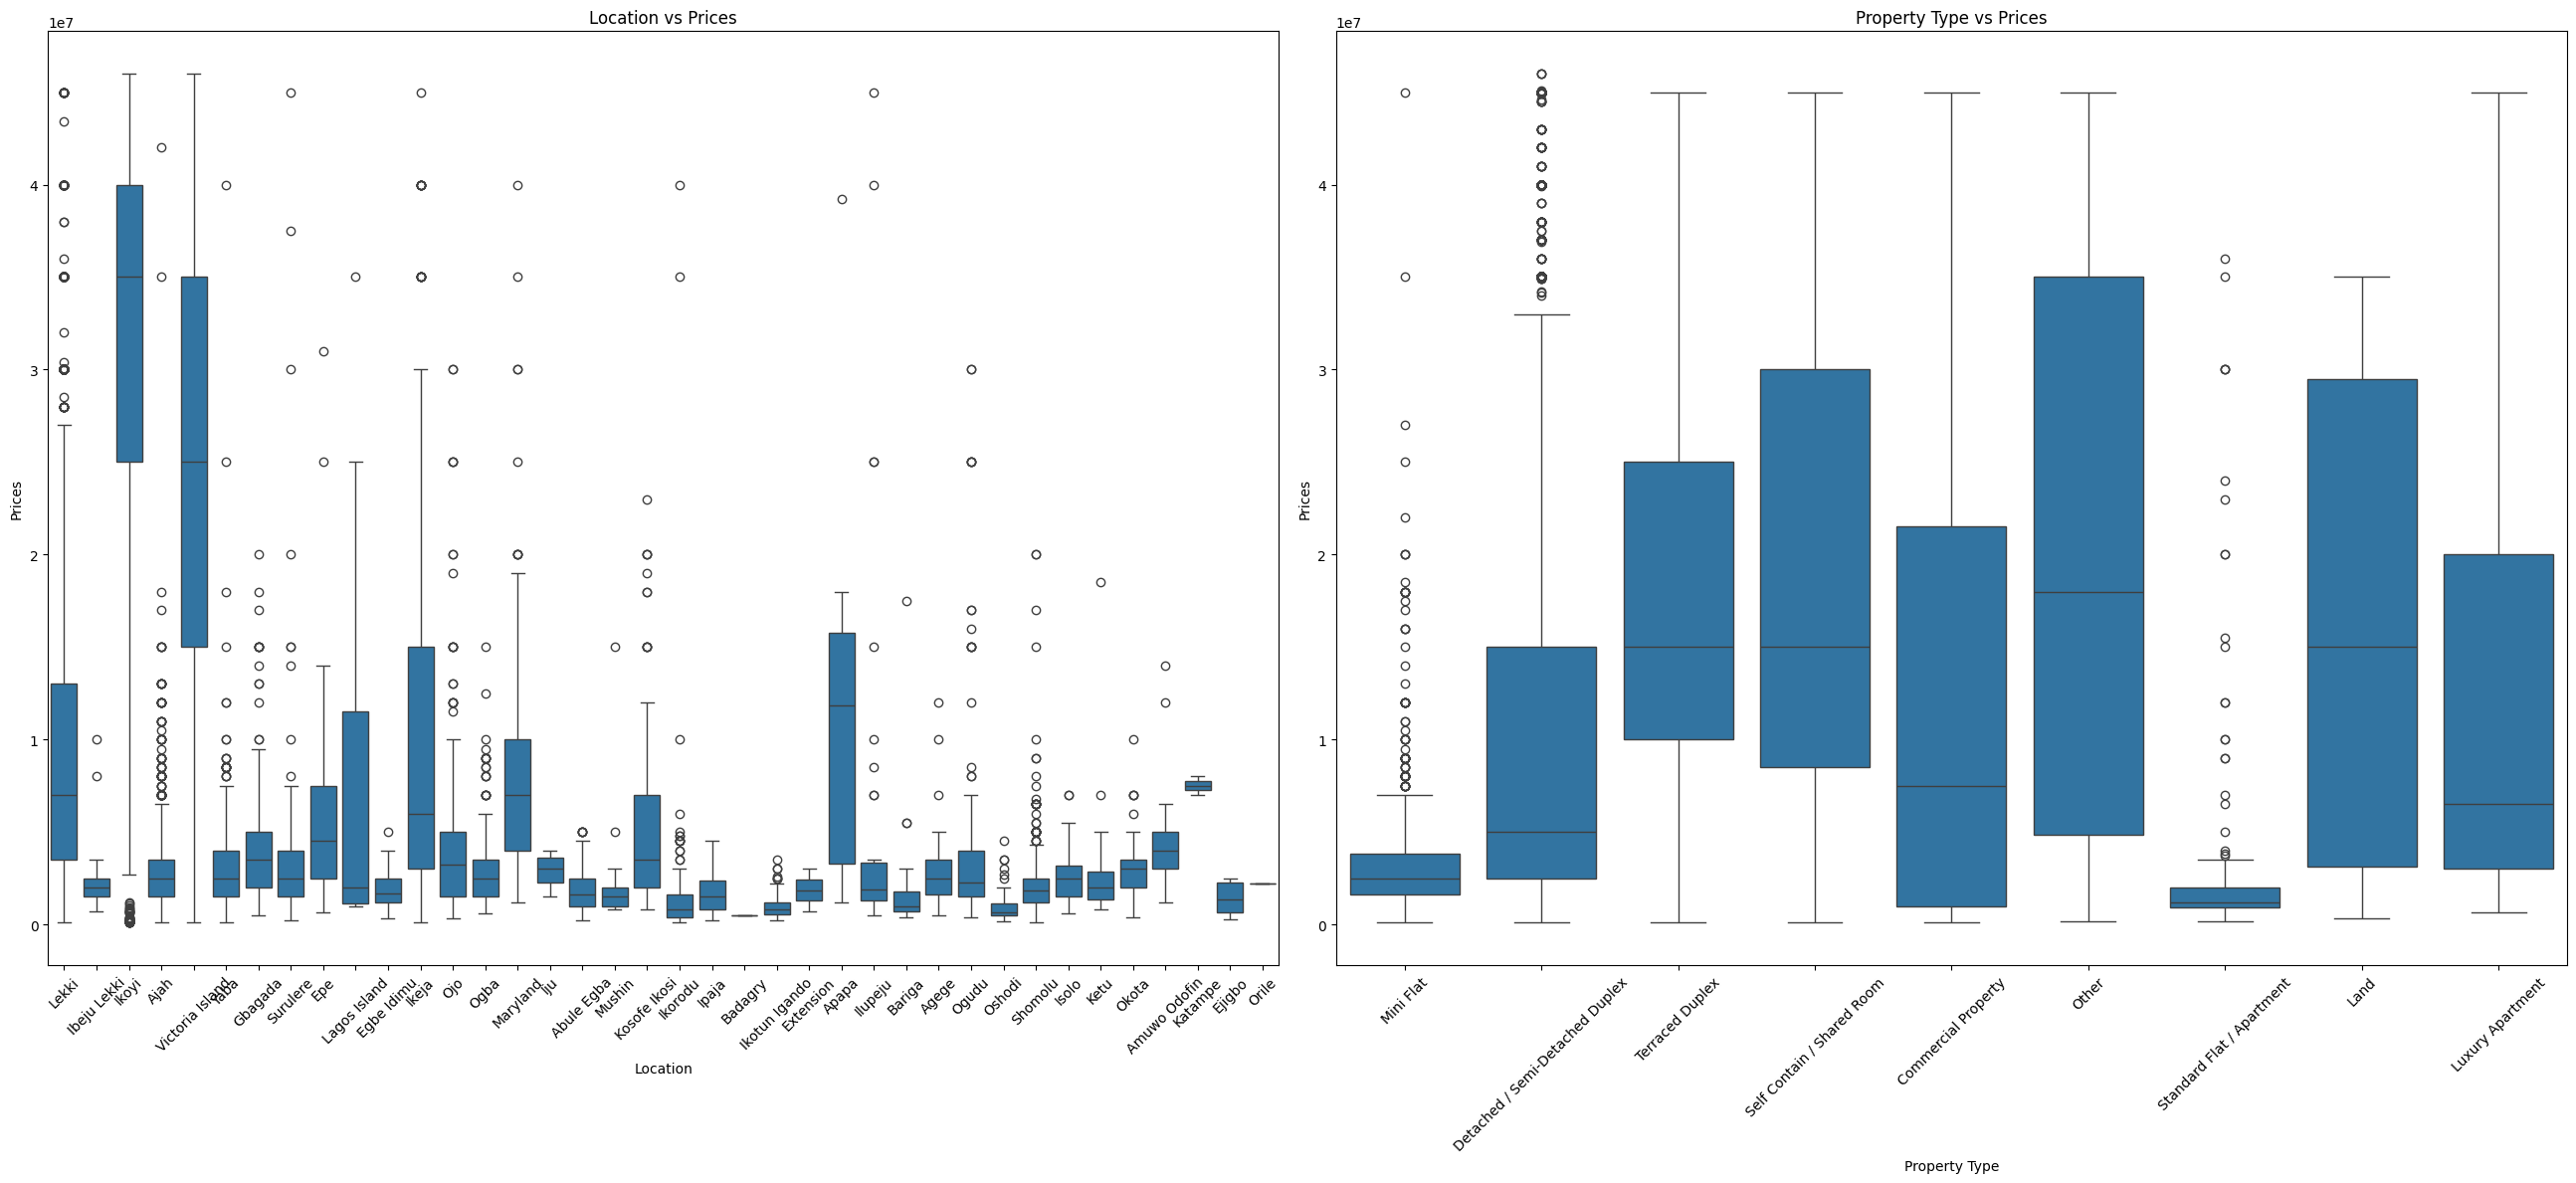

In [32]:
feats2 = ['Location', 'Property Type']
fig, ax = plt.subplots(1, 2, figsize = (26, 12))

for i, feat in enumerate(feats2):
  sns.boxplot(data = df, x = feat, y = 'Prices', ax = ax[i])
  ax[i].set_title(f'{feat} vs Prices')
  ax[i].set_xlabel(feat)
  ax[i].set_ylabel('Prices')
  ax[i].tick_params(axis = 'x', rotation = 45)

plt.tight_layout()
plt.show()

In [33]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# features = ['Property Type', 'Location', 'Bedrooms', 'Bathrooms']
# x_raw = df[features].copy()

cat_cols = ['Property Type', 'Location']

ct = ColumnTransformer(
  [
    (
      'cat',
      OneHotEncoder(
        handle_unknown = 'ignore',
        drop = 'first',
        sparse_output = False
      ),
      cat_cols
    ),
  ],
  remainder = 'passthrough'
)

x = ct.fit_transform(df.drop(columns = ['Prices', 'Price_label']))
y = df['Prices']

# A log transform is applied to the target to reduce the impact of very large price values.
y_log = np.log1p(y)


In [34]:
x

array([[0., 0., 0., ..., 0., 1., 1.],
       [1., 0., 0., ..., 0., 3., 3.],
       [0., 0., 0., ..., 0., 2., 3.],
       ...,
       [1., 0., 0., ..., 0., 1., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 1.]], shape=(15669, 47))

In [35]:
x_df = pd.DataFrame(x)
print(x_df.shape)  # shows (rows, columns)
print(x_df.head())

(15669, 47)
   0   1   2   3   4   5   6   7   8   9   ...  37  38  39  40  41  42  43  \
0   0   0   0   1   0   0   0   0   0   0  ...   0   0   0   0   0   0   0   
1   1   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   0   
2   0   0   0   1   0   0   0   0   0   0  ...   0   0   0   0   0   0   0   
3   0   0   0   0   0   0   0   1   0   0  ...   0   0   0   0   0   0   0   
4   0   0   0   0   0   0   0   1   0   0  ...   0   0   0   0   0   0   0   

   44  45  46  
0   0   1   1  
1   0   3   3  
2   0   2   3  
3   0   4   4  
4   0   3   3  

[5 rows x 47 columns]


In [36]:
x_train, x_test, y_train, y_test = train_test_split(
  x,
  y,
  test_size = 0.3,
  random_state = 42
)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(10968, 47)
(4701, 47)
(10968,)
(4701,)


In [37]:
lin_model = LinearRegression()
lin_model.fit(x_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [38]:
y_pred = lin_model.predict(x_test)

metrics = [
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
]

for metric in metrics:
  print(f'{metric.__name__}: {metric(y_test, y_pred)}')


mean_absolute_error: 4291247.512488537
mean_squared_error: 41891544301202.28
root_mean_squared_error: 6472367.750769597
r2_score: 0.6808525031791512


In [39]:
x2_train, x2_test, y2_train, y2_test = train_test_split(
  x,
  y,
  test_size = 0.2,
  random_state = 42
)

print(x2_train.shape)
print(x2_test.shape)
print(y2_train.shape)
print(y2_test.shape)


(12535, 47)
(3134, 47)
(12535,)
(3134,)


In [40]:
lin_model2 = LinearRegression()
lin_model2.fit(x2_train, y2_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [41]:
y2_pred = lin_model2.predict(x2_test)

metrics = [
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
]

for metric in metrics:
  print(f'{metric.__name__}: {metric(y2_test, y2_pred)}')


mean_absolute_error: 4326318.156726792
mean_squared_error: 41632731583041.26
root_mean_squared_error: 6452343.10797568
r2_score: 0.6805077662590151


In [42]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)
y_rf_pred = rf_model.predict(x_test)

print('MAE:', mean_absolute_error(y_test, y_rf_pred))
print('MSE:', mean_squared_error(y_test, y_rf_pred))
print('R2:', r2_score(y_test, y_rf_pred))


MAE: 3430087.2139739413
MSE: 33373473689140.508
R2: 0.7457467666619306


##### Our Regression models are performing poorly, even though the Random Forest regressor performed better.
Let's switch to Classifier models to see if there are any changes or progress.

In [43]:
y_class = df['Price_label']

x3_train, x3_test, y3_class_train, y3_class_test = train_test_split(
  x,
  y_class,
  test_size = 0.2,
  random_state = 42
)


x4_train, x4_test, y4_class_train, y4_class_test = train_test_split(
  x,
  y_class,
  test_size = 0.3,
  random_state = 42
)

In [44]:
logr_model = LogisticRegression(max_iter=1000)
logr_model.fit(x3_train, y3_class_train)
logr2_model = LogisticRegression(max_iter=1000)
logr2_model.fit(x4_train, y4_class_train)

logr_pred = logr_model.predict(x3_test)
logr2_pred = logr2_model.predict(x4_test)

print(
  classification_report(y3_class_test, logr_pred),
  classification_report(y4_class_test, logr2_pred),
  logr_model.score(x3_test, y3_class_test),
  logr2_model.score(x4_test, y4_class_test)
)


              precision    recall  f1-score   support

           0       0.89      0.93      0.91      1663
           1       0.75      0.73      0.74       963
           2       0.77      0.71      0.74       508

    accuracy                           0.83      3134
   macro avg       0.81      0.79      0.80      3134
weighted avg       0.83      0.83      0.83      3134
               precision    recall  f1-score   support

           0       0.89      0.94      0.91      2501
           1       0.76      0.72      0.74      1438
           2       0.77      0.71      0.74       762

    accuracy                           0.83      4701
   macro avg       0.81      0.79      0.80      4701
weighted avg       0.83      0.83      0.83      4701
 0.8337587747287811 0.8328015315890236


The Logistic Regression model achieved about 83% accuracy for both splits.
That means it correctly classified about 83 out of every 100 properties into the right price category.
- Class 0 performs best, with precision and recall around 0.89–0.94.
- Classes 1 and 2 are a bit weaker, with F1-scores around 0.74.
This suggests the model is good at identifying the budget category, but it struggles a bit more with the middle and luxury categories.

In [45]:
x5_train, x5_test, y_class_train, y_class_test = train_test_split(
  x,
  y_class,
  test_size = 0.2,
  random_state = 42
)

x6_train, x6_test, y2_class_train, y2_class_test = train_test_split(
  x,
  y_class,
  test_size = 0.3,
  random_state = 42
)


tree_model = DecisionTreeClassifier(random_state = 42)
tree_model.fit(x5_train, y_class_train)
tree2_model = DecisionTreeClassifier(random_state = 42)
tree2_model.fit(x6_train, y2_class_train)

tree_pred = tree_model.predict(x5_test)
tree2_pred = tree2_model.predict(x6_test)

print(
  confusion_matrix(y_class_test, tree_pred),
  classification_report(y_class_test, tree_pred),
  confusion_matrix(y2_class_test, tree2_pred),
  classification_report(y2_class_test, tree2_pred),
  tree_model.score(x5_test, y_class_test),
  tree2_model.score(x6_test, y2_class_test)
)


[[1569   84   10]
 [ 170  726   67]
 [  11  137  360]]               precision    recall  f1-score   support

           0       0.90      0.94      0.92      1663
           1       0.77      0.75      0.76       963
           2       0.82      0.71      0.76       508

    accuracy                           0.85      3134
   macro avg       0.83      0.80      0.81      3134
weighted avg       0.84      0.85      0.84      3134
 [[2358  127   16]
 [ 268 1069  101]
 [  20  196  546]]               precision    recall  f1-score   support

           0       0.89      0.94      0.92      2501
           1       0.77      0.74      0.76      1438
           2       0.82      0.72      0.77       762

    accuracy                           0.85      4701
   macro avg       0.83      0.80      0.81      4701
weighted avg       0.84      0.85      0.84      4701
 0.8471601786853861 0.8451393320570092


What the report means:
- Class 0: very strong performance, around 0.92 F1-score.
- Class 1: improved to about 0.76 F1-score.
- Class 2: improved to about 0.76 F1-score.

Macro average and weighted average are also higher than before.

> A decision tree classifier achieved about 85% accuracy in predicting property price categories, with strong performance for low-budget listings and solid results for mid-range and luxury listings.

These tree-based classification models perform better than the linear models for the price-band task.
They suggest that the relationship between features and price categories is not perfectly linear and that more flexible models may help with regression as well.

The classification models show that the data can be separated reasonably well into price bands.

The next step is to test whether log-transformation will improve the regression results for exact price prediction.

### LOG TRANSFORMATION:

In [46]:
x7_train, x7_test, y7_train, y7_test = train_test_split(
  x,
  y_log,
  test_size = 0.3,
  random_state = 42
)

lin_model3 = LinearRegression()
lin_model3.fit(x7_train, y7_train)


y_pred_log = lin_model3.predict(x7_test)

metrics = [
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
]

for metric in metrics:
  print(f'{metric.__name__}: {metric(y7_test, y_pred_log)}')


mean_absolute_error: 0.46554905765012616
mean_squared_error: 0.4879452710460612
root_mean_squared_error: 0.6985307946297438
r2_score: 0.6591489363578278


In [47]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x7_train, y7_train)
y_rf_pred_log = rf_model.predict(x7_test)

print('MAE:', mean_absolute_error(y7_test, y_rf_pred_log))
print('MSE:', mean_squared_error(y7_test, y_rf_pred_log))
print('R2:', r2_score(y7_test, y_rf_pred_log))

MAE: 0.398273260085597
MSE: 0.3557184322740895
R2: 0.7515151530461213


In [48]:
x_test

array([[1., 0., 0., ..., 0., 2., 2.],
       [1., 0., 0., ..., 0., 3., 3.],
       [1., 0., 0., ..., 0., 2., 2.],
       ...,
       [0., 0., 0., ..., 0., 1., 1.],
       [0., 0., 0., ..., 0., 4., 4.],
       [1., 0., 0., ..., 1., 3., 0.]], shape=(4701, 47))

In [49]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(x_train, y_train)

y_xgb_pred = xgb_model.predict(x_test)
print(
  'MAE:', mean_absolute_error(y_test, y_xgb_pred),
  '\nMSE:', mean_squared_error(y_test, y_xgb_pred),
  '\nRMSE:', root_mean_squared_error(y_test, y_xgb_pred),
  '\nR2:', r2_score(y_test, y_xgb_pred)
)

print('*' * 50)
print('** Now testing XGBoost on log-transformed target ***')
print('*' * 50)

x_train, x_test, ylog_train, ylog_test = train_test_split(
  x,
  y_log,
  test_size = 0.2,
  random_state = 42
)

xgb_model.fit(x_train, ylog_train)

ylog_xgb_pred = xgb_model.predict(x_test)
print(
  'MAE:', mean_absolute_error(ylog_test, ylog_xgb_pred),
  '\nMSE:', mean_squared_error(ylog_test, ylog_xgb_pred),
  '\nRMSE:', root_mean_squared_error(ylog_test, ylog_xgb_pred),
  '\nR2:', r2_score(ylog_test, ylog_xgb_pred)
)

MAE: 3432472.75 
MSE: 33521487839232.0 
RMSE: 5789774.5 
R2: 0.7446191310882568
**************************************************
** Now testing XGBoost on log-transformed target ***
**************************************************
MAE: 0.39856525880140437 
MSE: 0.3569594398985749 
RMSE: 0.5974608270828933 
R2: 0.7510626962049589


### Model performance summary

- Linear Regression (original Prices)
  - R2 = 0.65 showing 65% variation in house prices.
  - Performed poorly: large MAE/MSE and unstable predictions (some negative/unrealistic values).
  - Low explanatory power — not reliable for exact price prediction.

- Linear Regression (log-transformed target)
  - R2 = 0.75.
  - Noticeably better than using raw prices; reduced error and variance in predictions.
  - Still weaker than tree-based ensembles in overall fit.

- Random Forest Regressor
  - R2 ≈ 0.75 after log transform
  - Outperformed linear models. When trained/predicted on the log-transformed target it achieved the best regression results, with substantially lower MAE/MSE.
  - Best choice among tested regressors for this dataset.


- XGBoost Regression (original Prices)
  - R2 = 0.74 showing 65% variation in house prices.
  - Performed poorly: large MAE/MSE and unstable predictions (some negative/unrealistic values).
  - Low explanatory power — not reliable for exact price prediction.

- XGBoost Regression (log-transformed target)
  - R2 = 0.75.
  - Noticeably better than using raw prices; reduced error and variance in predictions.
  - Still weaker than tree-based ensembles in overall fit.

- Logistic Regression (price-band classification)
  - Accuracy ≈ 83%.
  - Very strong on class 0 (budget) — high precision & recall (~0.89–0.94).
  - Weaker on classes 1 & 2 (mid/luxury - because of the spread of prices, the model couldn't learn well on higher prices due to class imbalance), F1 ≈ 0.74.

- Decision Tree Classifier
  - Accuracy ≈ 85%, better than logistic regression.
  - Improved F1 for classes 1 & 2 (~0.76), more balanced class performance.

Conclusions / next steps
- Predicting discrete price bands is more successful than regressing exact prices.
- For regression, we should use log1p(Prices) + ensemble models (RandomForest / GradientBoosting / XGBoost) and cross-validated hyperparameter tuning.
- Improve features (location encodings, property-level metadata, external indices) and validate with CV to raise robustness.

## Cross-validation for regression

So far, the regression models were evaluated on a single train/test split. Cross-validation gives a more reliable estimate of how well the models generalize by testing them on several different folds of the data.

Cross-validation is a more robust way to evaluate a model because it repeatedly trains and tests on different subsets of the data. This helps reduce the risk of getting a good score by chance from a single random split.

Here, we will use 5-fold cross-validation on the log-transformed price target and compare a linear regression model with a random forest regressor.

In [50]:
from sklearn.model_selection import cross_val_score, KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)

lin_cv_scores = cross_val_score(
    LinearRegression(),
    x,
    y_log,
    cv=cv,
    scoring='r2'
)

rf_cv_scores = cross_val_score(
    RandomForestRegressor(n_estimators=100, random_state=42),
    x,
    y_log,
    cv=cv,
    scoring='r2'
)

xgb_cv_scores = cross_val_score(
    XGBRegressor(n_estimators = 100, random_state = 42),
    x,
    y_log,
    cv = cv,
    scoring = 'r2'
)

print('Linear Regression CV R2 scores:', lin_cv_scores)
print('Linear Regression CV mean R2:', round(lin_cv_scores.mean(), 4))
print('*' * 50)
print('*' * 50)
print('Random Forest CV R2 scores:', rf_cv_scores)
print('Random Forest CV mean R2:', round(rf_cv_scores.mean(), 4))
print('*' * 50)
print('*' * 50)
print('XGBoost CV R2 scores:', xgb_cv_scores)
print('XGBoost CV mean R2:', round(xgb_cv_scores.mean(), 4))


Linear Regression CV R2 scores: [0.65786636 0.69438038 0.67281475 0.67728009 0.70677227]
Linear Regression CV mean R2: 0.6818
**************************************************
**************************************************
Random Forest CV R2 scores: [0.75427242 0.75742097 0.75852187 0.77284568 0.75890259]
Random Forest CV mean R2: 0.7604
**************************************************
**************************************************
XGBoost CV R2 scores: [0.7510627  0.75739944 0.76034496 0.77504034 0.75490644]
XGBoost CV mean R2: 0.7598


### Cross-validation summary (5-fold, R2 on log1p(Prices))

- Setup: 5-fold KFold (shuffle=True, random_state=42), scoring = R2, target = log1p(Prices).
- Linear Regression
  - CV R2 scores: [0.6579, 0.6944, 0.6728, 0.6773, 0.7068]
  - Mean R2 ≈ 0.6818 — moderate explanatory power on the log-scale.
- Random Forest Regressor
  - CV R2 scores: [0.7543, 0.7574, 0.7585, 0.7728, 0.7589]
  - Mean R2 ≈ 0.7604 — clearly better than linear, more variance explained and more stable across folds.
- XGBoost Regressor
  - CV R2 scores: [0.7510  0.7573 0.7603 0.77504034 0.7549]
  - Mean R2 ≈ 0.7598 — still better than linear, but lagging a bit behind the tree regressor, more variance explained and more stable across folds.
- Interpretation: The random forest outperforms the linear and xgb regressor models for predicting log-prices, suggesting non-linear / interaction effects are important. R2 here reflects fit on the log-transformed target, so translate improvements back to original price scale when reporting final error metrics.
- Next steps: hyperparameter tuning (CV), richer features/encodings for location and property type, and evaluating final models on the original price scale (e.g., MAE on expm1 predictions).

In [51]:
df.describe()

,Bedrooms,Bathrooms,Prices
count,"15,669","15,669","15,669"
mean,2,2,"10,262,536"
std,1,1,"11,594,588"
min,0,0,"100,000"
25%,1,1,"2,300,000"
50%,2,2,"5,000,000"
75%,3,3,"15,000,000"
max,10,10,"46,000,000"


In [52]:
display(
    df[df['Prices'] <= 11000000].shape,
    df[(df['Prices'] <= 11000000) & (df['Prices'] <= 13000000)].shape,
    df[(df['Prices'] > 13000000) & (df['Prices'] <= 15000000)].shape,
    df[(df['Prices'] > 15000000) & (df['Prices'] <= 20000000)].shape,
    df[df['Prices'] > 20000000].shape
)

(10993, 6)

(10993, 6)

(621, 6)

(878, 6)

(2625, 6)

In [53]:
min_price_df = df[df['Prices'] <= 11000000]

In [54]:
min_price_df.shape

(10993, 6)

In [55]:
min_price_df

,Property Type,Location,Bedrooms,Bathrooms,Prices,Price_label
0,Mini Flat,Lekki,1,1,3200000,0
2,Mini Flat,Ibeju Lekki,2,3,2500000,0
5,Terraced Duplex,Lekki,3,3,9000000,1
6,Detached / Semi-Detached Duplex,Lekki,2,2,8000000,1
11,Detached / Semi-Detached Duplex,Lekki,1,1,1900000,0
...,...,...,...,...,...,...
18874,Mini Flat,Ikorodu,1,2,750000,0
18875,Detached / Semi-Detached Duplex,Lekki,0,0,1500000,0
18877,Detached / Semi-Detached Duplex,Ajah,1,1,1300000,0
18878,Detached / Semi-Detached Duplex,Lekki,0,0,1700000,0


In [56]:
min_price_df.onehot_encode = ct.fit_transform(min_price_df.drop(columns = ['Prices', 'Price_label']))

/tmp/ipykernel_13008/2488874612.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  min_price_df.onehot_encode = ct.fit_transform(min_price_df.drop(columns = ['Prices', 'Price_label']))


In [57]:
min_x = ct.fit_transform(min_price_df.drop(columns = ['Prices', 'Price_label']))
min_y = min_price_df['Prices']
min_y_class = min_price_df['Price_label']


min_x_train, min_x_test, min_y_train, min_y_test = train_test_split(
    min_x,
    min_y,
    test_size = 0.2,
    random_state = 42
)

min_li_model = LinearRegression()
min_li_model.fit(min_x_train, min_y_train)

min_y_pred = min_li_model.predict(min_x_test)
print('*' * 50)
print(
    'MAE:', mean_absolute_error(min_y_test, min_y_pred),
    '\nMSE:', mean_squared_error(min_y_test, min_y_pred),
    '\nRMSE:', root_mean_squared_error(min_y_test, min_y_pred),
    '\nR2 Score:', r2_score(min_y_test, min_y_pred)
)
print('*' * 50)

**************************************************
MAE: 1364355.1583523424 
MSE: 3725504261128.877 
RMSE: 1930156.537985683 
R2 Score: 0.4721957110216717
**************************************************


In [58]:
min_y_log = np.log1p(min_y)


min_x_train, min_x_test, min_ylog_train, min_ylog_test = train_test_split(
    min_x,
    min_y_log,
    test_size = 0.2,
    random_state = 42
)

min_li_model = LinearRegression()
min_li_model.fit(min_x_train, min_ylog_train)

min_ylog_pred = min_li_model.predict(min_x_test)


print('** Now testing Linear Regression on log-transformed target ***')
print('*' * 50)
print(
    'MAE:', mean_absolute_error(min_ylog_test, min_ylog_pred),
    '\nMSE:', mean_squared_error(min_ylog_test, min_ylog_pred),
    '\nRMSE:', root_mean_squared_error(min_ylog_test, min_ylog_pred),
    '\nR2 Score:', r2_score(min_ylog_test, min_ylog_pred)
)
print('*' * 50)

** Now testing Linear Regression on log-transformed target ***
**************************************************
MAE: 0.41675301372897194 
MSE: 0.38177958794254774 
RMSE: 0.6178831507190884 
R2 Score: 0.44243758963477564
**************************************************


In [59]:
min_y_log.describe()

count   10,993
mean        15
std          1
min         12
25%         14
50%         15
75%         15
max         16
Name: Prices, dtype: float64

In [60]:
min_xgb_model = XGBRegressor()
min_xgb_model.fit(min_x_train, min_y_train)

min_xgb_y_pred = min_xgb_model.predict(min_x_test)

print('R2 Score:', r2_score(min_y_test, min_xgb_y_pred))

R2 Score: 0.6556974649429321


In [61]:
min_xgb_model = XGBRegressor()
min_xgb_model.fit(min_x_train, min_ylog_train)

min_xgb_y_pred = min_xgb_model.predict(min_x_test)

print('R2 Score:', r2_score(min_ylog_test, min_xgb_y_pred))

R2 Score: 0.6540627540090549


In [62]:
min_rf_model = RandomForestRegressor(n_estimators = 100, random_state = 42)
min_rf_model.fit(min_x_train, min_y_train)

min_rf_y_pred = min_rf_model.predict(min_x_test)

print('R2 Score:', r2_score(min_y_test, min_rf_y_pred))

R2 Score: 0.6525967952084881


In [63]:
min_rf_model = RandomForestRegressor(n_estimators = 100, random_state = 42)
min_rf_model.fit(min_x_train, min_ylog_train)

min_rf_ylog_pred = min_rf_model.predict(min_x_test)

print('R2 Score:', r2_score(min_ylog_test, min_rf_ylog_pred))

R2 Score: 0.6506139295981943


In [64]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Build a richer model-ready dataset from the Lagos subset
model_df = data[data['State'].str.contains('Lagos')].copy()

# Create better date-based and text-based features
model_df['Date Listed'] = pd.to_datetime(model_df['Date Listed'], errors='coerce')
model_df['listed_month'] = model_df['Date Listed'].dt.month
model_df['listed_weekday'] = model_df['Date Listed'].dt.weekday
model_df['days_since_listed'] = (pd.Timestamp.today().normalize() - model_df['Date Listed'].dt.normalize()).dt.days
model_df['days_since_listed'] = model_df['days_since_listed'].clip(lower=0)
model_df['title_length'] = model_df['Title'].fillna('').str.len()
model_df['has_shortlet'] = model_df['Title'].fillna('').str.lower().str.contains('shortlet', na=False).astype(int)
model_df['has_duplex'] = model_df['Title'].fillna('').str.lower().str.contains('duplex', na=False).astype(int)

# Keep the most useful columns
model_df = model_df[
    ['Prices', 'Bedrooms', 'Bathrooms', 'Toilets', 'Property Type', 'Location',
     'listed_month', 'listed_weekday', 'days_since_listed', 'title_length',
     'has_shortlet', 'has_duplex']
].copy()

# Convert numeric columns safely
for col in ['Bedrooms', 'Bathrooms', 'Toilets', 'Prices']:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

model_df = model_df.dropna(subset=['Prices', 'Bedrooms', 'Bathrooms', 'Toilets', 'Property Type', 'Location'])

# Remove extreme price outliers using the IQR rule
q1 = model_df['Prices'].quantile(0.25)
q3 = model_df['Prices'].quantile(0.75)
iqr = q3 - q1
model_df = model_df[(model_df['Prices'] >= q1 - 1.5 * iqr) & (model_df['Prices'] <= q3 + 1.5 * iqr)].copy()

X = model_df.drop(columns=['Prices'])
y = model_df['Prices']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output = False))
])

preprocess = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

models = {
    'RandomForest': RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    'HistGradientBoosting': HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=4,
        max_iter=300,
        random_state=42
    )
}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocess', preprocess),
        ('model', model)
    ])
    pipe.fit(X_train, np.log1p(y_train))
    preds = np.expm1(pipe.predict(X_test))
    mae = mean_absolute_error(y_test, preds)
    rmse = root_mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f'{name} -> MAE: {mae:,.0f} | RMSE: {rmse:,.0f} | R2: {r2:.3f}')


RandomForest -> MAE: 3,311,105 | RMSE: 5,847,481 | R2: 0.738
HistGradientBoosting -> MAE: 3,452,715 | RMSE: 6,011,983 | R2: 0.723


### Conclusion

This notebook set out to explore whether property characteristics from Nigerian real estate listings could be used to reliably predict house prices. After working through data cleaning, exploratory analysis, feature engineering, and iterative modeling, a few clear patterns emerged.

Here's the restructured version incorporating the cross-validation results:

- On the regression side, three models were evaluated; Linear Regression, Random Forest, and XGBoost; all trained on log-transformed prices for better handling of skewed distributions. To ensure reliable evaluation, 5-fold cross-validation was used rather than a single train/test split.
    - The Random Forest model came out on top with a cross-validated R² of **0.7604**,
    - Closely followed by XGBoost at **0.7598**.
    - Both tree-based models significantly outperformed Linear Regression **`(CV R² of 0.6818)`**, confirming that the relationship between property features and price is inherently nonlinear.

The consistency of scores across all five folds also indicates that the models are stable and not overfitting, a key requirement before deployment.

- The classification models told an equally encouraging story:
    - The Decision Tree classifier achieved **85% accuracy** in categorizing properties into budget, mid-range, and luxury price bands, suggesting that while exact price prediction carries some uncertainty, broad price category prediction is quite feasible with this data.

    - The key limitation throughout was the dataset itself. Without floor area, property condition, or street-level location data, there is a natural ceiling on how accurate any model can be, and a cross-validated **R² of ~0.76** likely represents close to that ceiling for this feature set. Future work would benefit significantly from richer, more granular data sources.

Overall, this project demonstrates a complete end-to-end machine learning workflow, from raw data through cleaning, exploratory analysis, feature engineering, iterative modeling, and cross-validated evaluation, thereby laying the groundwork for a deployable property price prediction tool.

### Deployment

Exporting our best performing Regression model for production use.

In [68]:
import joblib

# Use the same columns  used before
features = ['Property Type', 'Location', 'Bedrooms', 'Bathrooms']
X_raw = df[features].copy()
y_raw = df['Prices']

# Step 2: Define which columns are categorical and numeric
cat_cols = ['Property Type', 'Location']
num_cols = ['Bedrooms', 'Bathrooms']

# Step 3: Build a fresh preprocessor
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', 'passthrough', num_cols)
])

# Step 4: Build the full pipeline
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Step 5: Fit and export
X_raw_train, X_raw_test, y_raw_train, y_raw_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

full_pipeline.fit(X_raw_train, y_raw_train)

# Verify it still performs well
# preds = np.expm1(
pred = full_pipeline.predict(X_raw_test)
#actuals = np.expm1(y_raw_test)
print('R2:', r2_score(y_raw_test, pred))

# Step 6: Save it
joblib.dump(full_pipeline, 'house_price_model.pkl')
print('Model saved!')

R2: 0.75763266091791
Model saved!
